In [ ]:
!git clone https://github.com/E-tech-coder/DataScienceCapstoneProject.git

Cloning into 'DataScienceCapstoneProject'...
remote: Enumerating objects: 290, done.
remote: Counting objects: 100% (78/78), done.
remote: Compressing objects: 100% (58/58), done.
remote: Total 290 (delta 62), reused 20 (delta 20), pack-reused 212 (from 2)
Receiving objects: 100% (290/290), 2.12 MiB | 10.32 MiB/s, done.
Resolving deltas: 100% (162/162), done.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

 # Zero-shot classification using a pretrained NLI model

In [ ]:
from transformers import pipeline

# Model:"joeddav/xlm-roberta-large-xnli"
# This model takes xlm-roberta-large and fine-tunes it on a combination of NLI data in 15 languages.
# This model is intended to be used for zero-shot text classification, especially in languages other than English. It is fine-tuned on XNLI, which is a multilingual NLI dataset.

pipe = pipeline("zero-shot-classification",model="joeddav/xlm-roberta-large-xnli")


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/734 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.24G [00:00<?, ?B/s]

Some weights of the model checkpoint at joeddav/xlm-roberta-large-xnli were not used when initializing XLMRobertaForSequenceClassification: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
- This IS expected if you are initializing XLMRobertaForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing XLMRobertaForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

Device set to use cuda:0


We load a zero-shot classification pipeline from Hugging Face.

The model joeddav/xlm-roberta-large-xnli is:

  * Based on XLM-RoBERTa-large
  * Fine-tuned on XNLI (Cross-lingual Natural Language Inference) data
  * Designed to classify text without task-specific training

Zero-shot classification works by reframing classification as an NLI task:
  * Premise: the input text (job position)
  * Hypothesis: “This text belongs to category X”

This makes the model suitable when labeled training data is limited or unavailable.

In [ ]:
df = pd.read_csv("/content/DataScienceCapstoneProject/department.csv")
# Predict department with a pretrained model based on position name
dpt_labels = df["label"].drop_duplicates()
text = df["text"].tolist()
candidate_labels = dpt_labels
result = pipe(text, candidate_labels)

* candidate_labels are all unique department names in the dataset.
* Each job position is classified against all department labels.
* The model returns a ranked list of labels for each position with confidence scores.

The dataset contains job profiles with fields such as:
position, department, seniority

# Zero-shot prediction of department (Department.csv)

In [ ]:
df = pd.read_csv("/content/DataScienceCapstoneProject/department.csv")

In [ ]:
prediction = []
# For each position, we take the top-ranked predicted department.
for i in range(len(result)):
  prediction.append(result[i]["labels"][0])

# Evaluation
from sklearn.metrics import classification_report
true_label = df["label"].astype(str)
print(classification_report(true_label, prediction))

                        precision    recall  f1-score   support

        Administrative       0.15      0.40      0.22        83
  Business Development       0.55      0.53      0.54       620
            Consulting       0.23      0.74      0.35       167
      Customer Support       0.06      0.18      0.09        33
       Human Resources       0.15      0.97      0.26        31
Information Technology       0.60      0.72      0.65      1305
             Marketing       0.94      0.79      0.86      4295
                 Other       0.08      0.45      0.13        42
    Project Management       0.35      0.77      0.48       201
            Purchasing       0.68      0.85      0.76        40
                 Sales       0.94      0.73      0.82      3328

              accuracy                           0.74     10145
             macro avg       0.43      0.65      0.47     10145
          weighted avg       0.83      0.74      0.77     10145



# Result interpretation (Department.csv file)

## Accuracy = 74%
When we use only the job title to predict the department in the "department.csv" file, xlm-roberta-large-xnli captures semantic meaning of job titles.
Especially useful in multilingual or non-standard job naming contexts.

# Zero-shot prediction of department (Linkedin CV test data)

In [ ]:
df = pd.read_csv("/content/DataScienceCapstoneProject/df_profiles_cleansed.csv")
# Predict department with a pretrained model based on position name
dpt_labels = df["department"].drop_duplicates()
text = df["position"].tolist()
candidate_labels = dpt_labels
result = pipe(text, candidate_labels)

prediction = []
# For each position, we take the top-ranked predicted department.
for i in range(len(result)):
  prediction.append(result[i]["labels"][0])

# Evaluation
from sklearn.metrics import classification_report
true_label = df["department"].astype(str)
print(classification_report(true_label, prediction))


                        precision    recall  f1-score   support

        Administrative       0.15      0.54      0.23        84
  Business Development       0.49      0.51      0.50        78
            Consulting       0.46      0.62      0.53       195
      Customer Support       0.62      0.60      0.61        48
       Human Resources       0.30      0.91      0.45        69
Information Technology       0.69      0.63      0.66       309
             Marketing       0.58      0.40      0.47       133
                 Other       0.73      0.53      0.61      1235
    Project Management       0.74      0.68      0.70       173
            Purchasing       0.32      0.60      0.42        72
                 Sales       0.79      0.51      0.62       219

              accuracy                           0.56      2615
             macro avg       0.53      0.59      0.53      2615
          weighted avg       0.65      0.56      0.59      2615



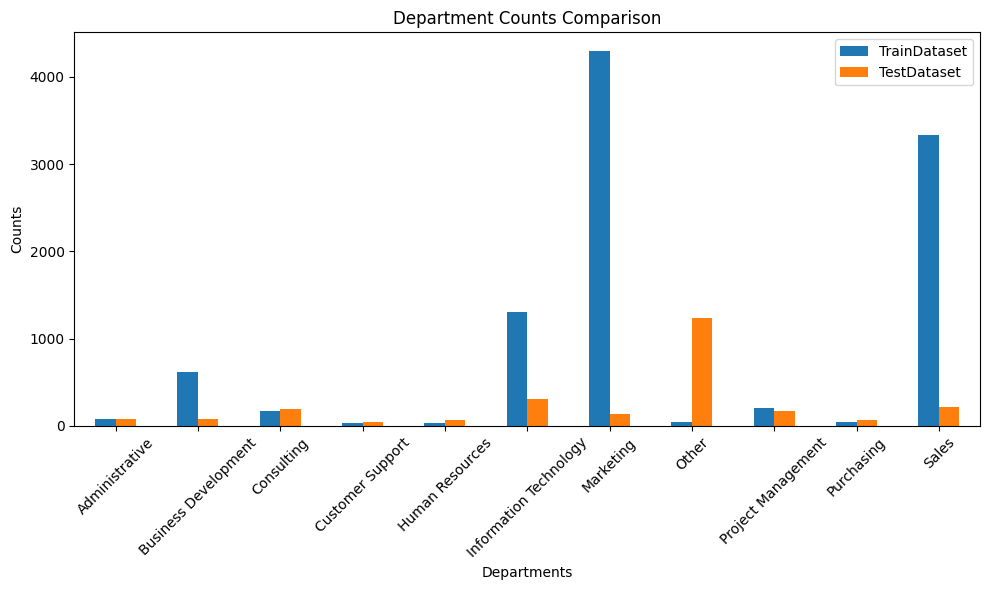

In [ ]:
# Department values counts from "department.csv"
departments = pd.read_csv("/content/DataScienceCapstoneProject/department.csv")
counts1 = departments["label"].value_counts()
# Department values counts from linkedin CV
df = pd.read_csv("/content/DataScienceCapstoneProject/df_profiles_cleansed.csv")
counts2 = df["department"].value_counts()

counts = pd.DataFrame(
    {
        "TrainDataset": counts1,
        "TestDataset": counts2
    }
)
counts.plot(kind = "bar", figsize = (10,6))
plt.xlabel("Departments")
plt.ylabel("Counts")
plt.title("Department Counts Comparison")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Result interpretation (Linkedin CV test file)
Accuracy = 56%

When we use only the job title to predict the department in the linkedin CV file, xlm-roberta-large-xnli reached a lower accuracy.

One of the possible reasons is that the label distribution here in the CV test data is quite different from the Department dataset.
For example, in the Department dataset,it includes around
* 40% is Marketing,
* 30% is Sales,
* 10% Information technology,
* only 0.42% is Other.

But in the linkedin CV test dataset,
* almost 50% of the data is Other department.

This Label distribution shift leads to the big difference in prediction accuracy.

Additionally, using job titles alone provides limited semantic information, further increasing ambiguity.

As a result, accuracy is not a reliable metric under these conditions, and the observed performance degradation is expected.

### Let's test the accuracy on the Linkedin CV file without "Other" department


In [ ]:
df = pd.read_csv("/content/DataScienceCapstoneProject/df_profiles_cleansed.csv")
df = df[df["department"]!= "Other"]
# Predict department with a pretrained model based on position name
dpt_labels = df["department"].drop_duplicates().astype(str).tolist()
text = df["position"].tolist()
candidate_labels = dpt_labels
result = pipe(text, candidate_labels)

prediction = []
# For each position, we take the top-ranked predicted department.
for i in range(len(result)):
  prediction.append(result[i]["labels"][0])

# Evaluation
from sklearn.metrics import classification_report
true_label = df["department"].astype(str)
print(classification_report(true_label, prediction))

                        precision    recall  f1-score   support

        Administrative       0.32      0.64      0.43        84
  Business Development       0.68      0.53      0.59        78
            Consulting       0.60      0.70      0.64       195
      Customer Support       0.64      0.62      0.63        48
       Human Resources       0.49      0.94      0.64        69
Information Technology       0.73      0.65      0.69       309
             Marketing       0.76      0.46      0.57       133
    Project Management       0.77      0.75      0.76       173
            Purchasing       0.50      0.61      0.55        72
                 Sales       0.86      0.53      0.65       219

              accuracy                           0.64      1380
             macro avg       0.64      0.64      0.62      1380
          weighted avg       0.69      0.64      0.64      1380



After removing the data labeled with "Other" department, we see an  increase in the general accuracy of the zero shot prediction, leading to 64%. But compared to the 56% accuracy before the "Other" department data is removed, this is not a huge increase.

# Attempt to fine-tune the model on labeled department data

xlm-roberta-large-xnli showed acceptable overall zero-shot performance, and we attempted to:

* Fine-tune it using department dataset
* Evaluate on Linkedin CV dataset
* Expect improved task-specific accuracy

### Label Encoding

In [ ]:
from sklearn.preprocessing import LabelEncoder
# Departments are converted from strings → numeric labels
# Required for supervised training
departments = pd.read_csv("/content/DataScienceCapstoneProject/department.csv")
le = LabelEncoder()
codes = le.fit_transform(departments["label"].drop_duplicates())
dpt = le.inverse_transform(codes)
mapping = dict(zip(dpt, codes))

departments["labels"] = departments["label"].map(mapping)
train_dataset = departments.drop(columns = "label").rename(columns={"text":"position"})

# Encode "department" in evaluation dataset
df = pd.read_csv("/content/DataScienceCapstoneProject/df_profiles_cleansed.csv")[["position","department"]]
df["labels"] = df["department"].map(mapping)
eval_dataset = df.drop(columns = "department")

In [ ]:
eval_dataset

,position,labels
0,Prokurist,7
1,CFO,7
2,Betriebswirtin,7
3,Prokuristin,7
4,CFO,7
...,...,...
2610,Justitiar,7
2611,Geschäftsführer,7
2612,Präsidium,7
2613,Rechtsanwalt,7


### Prepare training and evaluation dataset



In [ ]:
from datasets import Dataset
train_dataset = Dataset.from_pandas(train_dataset)
eval_dataset = Dataset.from_pandas(eval_dataset)

In [ ]:
eval_dataset

Dataset({
    features: ['position', 'labels'],
    num_rows: 2615
})

In [ ]:
train_dataset

Dataset({
    features: ['position', 'labels'],
    num_rows: 10145
})

### Tokenization

In [ ]:
from transformers import AutoTokenizer

model_name = "joeddav/xlm-roberta-large-xnli"
tokenizer = AutoTokenizer.from_pretrained(model_name)

# Converts text into:input_ids, attention_mask
# max_length=106 is chosen based on job title length

def tokenize(batch):
  return tokenizer(batch["position"], truncation=True, padding = "max_length", max_length = 106)

train_dataset = train_dataset.map(tokenize, batched = True)
train_dataset.set_format("torch", columns=["input_ids", "attention_mask", "labels"])

eval_dataset = train_dataset.map(tokenize, batched = True)
eval_dataset.set_format("torch", columns=["input_ids", "attention_mask", "labels"])

Map:   0%|          | 0/10145 [00:00<?, ? examples/s]

Map:   0%|          | 0/10145 [00:00<?, ? examples/s]

In [ ]:
train_dataset

Dataset({
    features: ['position', 'labels', 'input_ids', 'attention_mask'],
    num_rows: 10145
})

### Model initialization for supervised classification

In [ ]:
 id2label = {int(k):str(v) for k,v in zip(codes, dpt)}
 label2id = {str(v):int(k) for k,v in id2label.items()}

from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels = len(label2id),
    id2label=id2label,
    label2id = label2id,
    ignore_mismatched_sizes = True
)

model.safetensors:   0%|          | 0.00/2.24G [00:00<?, ?B/s]

Some weights of the model checkpoint at joeddav/xlm-roberta-large-xnli were not used when initializing XLMRobertaForSequenceClassification: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
- This IS expected if you are initializing XLMRobertaForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing XLMRobertaForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at joeddav/xlm-roberta-large-xnli and are newly initialized because the shapes did not match:
- classifier.out_proj.bias: found shape torch.Size([3]) in the checkpoint and torch.Size([11]) in the

* We redefine the classification head to predict departments
* ignore_mismatched_sizes=True forces reinitialization of the output layer
* Consequence: The original NLI classification head (entailment / neutral / contradiction) is discarded

### Training and evaluation

In [ ]:
# Train the model
from transformers import Trainer, TrainingArguments
training_args = TrainingArguments(
    "test_trainer", report_to="none")

In [ ]:
!pip install evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 5.7 MB/s eta 0:00:00


In [ ]:
import numpy as np
import evaluate

metric = evaluate.load("accuracy")
def compute_metrics(eval_pred):
  logits,labels = eval_pred
  predictions = np.argmax(logits, axis = -1)
  return metric.compute(predictions=predictions, references=labels)

In [ ]:
trainer = Trainer(
  model = model,
  args = training_args,
  train_dataset = train_dataset,
  eval_dataset = eval_dataset,
  compute_metrics = compute_metrics
)

trainer.evaluate()

{'eval_loss': 2.3762354850769043,
 'eval_model_preparation_time': 0.0689,
 'eval_accuracy': 0.12863479546574666,
 'eval_runtime': 218.3421,
 'eval_samples_per_second': 46.464,
 'eval_steps_per_second': 5.812}

## Result interpretation (after training)
## Accuracy = 13%

This is much worse than the 56% zero-shot accuracy.

### Why performance collapses after training

After traing, our model accuracy on evaluation data comes down to only 11%, compared to 56% before training. It seems that our model is broken after training.
Here are the possible reasons :

### Reason
xlm-roberta-large-xnli is not a standard classifier. It is trained for Natural Language Inference (NLI):
premise + hypothesis → {entailment, neutral, contradiction}
Zero-shot classification works because Hugging Face reformulates classification as NLI:
* Premise: The initial statement or context.
* Hypothesis: The statement being tested for truth relative to the premise.

Relationships:
1. Entailment: The premise logically implies the hypothesis (e.g., Premise: "A cat is on the mat." Hypothesis: "A feline is on a rug.").
2. Contradiction: The premise logically refutes the hypothesis (e.g., Premise: "The sun rises in the east." Hypothesis: "The sun never rises.").
3. Neutral: The hypothesis is neither confirmed nor denied by the premise.

When we fine-tuned it directly on:
*   input: job_position
*   label: department
The NLI alignment that makes zero-shot work is destroyed.


# Conclusion

* Zero-shot classification with xlm-roberta-large-xnli is: Effective
, Data-efficient, Suitable for this task.

* Fine-tuning this model directly is not appropriate.
It is not a standard classifier
Its strength lies in NLI-based zero-shot inference.

* For supervised learning, a better approach would be:
A model pretrained for sequence classification.
Or reformulating training data explicitly as NLI pairs